In [2]:
%pip install tensorflow
import tensorflow as tf

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.36.2 which is incompatible.


   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.3/351.2 MB 8.4 MB/s eta 0:00:42
   ---------------------------------------- 3.7/351.2 MB 10.2 MB/s eta 0:00:34
    --------------------------------------- 6.6/351.2 MB 11.5 MB/s eta 0:00:30
   - -------------------------------------- 9.4/351.2 MB 12.3 MB/s eta 0:00:28
   - -------------------------------------- 13.1/351.2 MB 13.3 MB/s eta 0:00:26
   - -------------------------------------- 17.3/351.2 MB 14.5 MB/s eta 0:00:24
   -- ------------------------------------- 23.1/351.2 MB 16.5 MB/s eta 0:00:20
   --- ------------------------------------ 30.9/351.2 MB 19.3 MB/s eta 0:00:17
   ---- ----------------------------------- 39.6/351.2 MB 21.8 MB/s eta 0:00:15
   ----- ---------------------------------- 48.5/351.2 MB 23.9 MB/s eta 0:00:13
   ------ --------------------------------- 56.9/351.2 MB 25.4 MB/s eta 0:00:12
   ------- -------------------------------- 66.3/351.2

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [12]:
DIR = r"C:\Users\Tushar\Downloads\archive\dataset"

IMG_SIZE =(128,128)
Batch_Size = 32 

train_data = keras.utils.image_dataset_from_directory(DIR , 
                                                      validation_split=0.2 , 
                                                      image_size = IMG_SIZE , 
                                                      batch_size=Batch_Size , 
                                                      seed=123, 
                                                      subset="training" , 
                                                      label_mode = "binary")

test_data = keras.utils.image_dataset_from_directory(DIR,
                                                   validation_split=0.2,
                                                   subset = "validation",
                                                   seed=123,
                                                   image_size=IMG_SIZE,
                                                   batch_size = Batch_Size,
                                                   label_mode='binary')
                            


Found 3068 files belonging to 2 classes.
Using 2455 files for training.
Found 3068 files belonging to 2 classes.
Using 613 files for validation.


In [13]:
def normalize(x,y):
    x = x/255.0
    return x,y

train_data = train_data.map(normalize)
test_data=test_data.map(normalize)

In [16]:
model = keras.Sequential([
    layers.Input(shape=(128,128,3)),

    layers.Conv2D(32,(3,3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(64,(3,3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(128,(3,3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Flatten(),
    layers.Dense(128 , activation="relu"),
    layers.Dense(1 , activation="sigmoid")

    
])

In [17]:
model.compile(optimizer = "adam",
             loss = "binary_crossentropy",
             metrics = ["accuracy"]
             )

In [18]:
history = model.fit(train_data , validation_data=test_data , epochs=10)

Epoch 1/10


C:\Users\Tushar\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


77/77 ━━━━━━━━━━━━━━━━━━━━ 15s 171ms/step - accuracy: 0.6615 - loss: 0.6662 - val_accuracy: 0.6705 - val_loss: 0.6297
Epoch 2/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - accuracy: 0.6770 - loss: 0.6098 - val_accuracy: 0.6737 - val_loss: 0.6748
Epoch 3/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step - accuracy: 0.6982 - loss: 0.5730 - val_accuracy: 0.6949 - val_loss: 0.5963
Epoch 4/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 0.7332 - loss: 0.5366 - val_accuracy: 0.6884 - val_loss: 0.6168
Epoch 5/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.7796 - loss: 0.4652 - val_accuracy: 0.7292 - val_loss: 0.5810
Epoch 6/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.8122 - loss: 0.4027 - val_accuracy: 0.7308 - val_loss: 0.6007
Epoch 7/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - accuracy: 0.8481 - loss: 0.3512 - val_accuracy: 0.7227 - val_loss: 0.7664
Epoch 8/10
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step - accuracy: 0.8819 - loss: 0.2789 - val_accuracy: 0.760

In [19]:
loss , acc = model.evaluate(test_data)
print(loss)
print(acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.7520 - loss: 0.9075
0.9075093269348145
0.7520391345024109


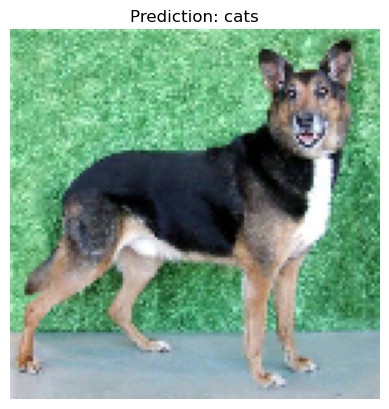

Prediction: cats


In [28]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class names
class_names = ['dogs', 'cats']

# Image path
img_path = r"C:\Users\Tushar\Downloads\archive\dataset\dogs\dog.2816.jpg"

# Load image
img = load_img(img_path, target_size=(128, 128))

# Convert image to array
img_array = img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array, verbose=0)[0][0]

# Convert prediction to class
if prediction >= 0.5:
    result = class_names[1]
else:
    result = class_names[0]

# Display image
plt.imshow(img)
plt.title(f"Prediction: {result}")
plt.axis("off")
plt.show()

print("Prediction:", result)